# Spatial Machine Learning Models



In [23]:

import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.neighbors import KernelDensity
from sklearn.cluster import DBSCAN
import hdbscan

from sklearn.mixture import GaussianMixture
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.labelcolor': 'black',
    'xtick.color': 'black', 'ytick.color': 'black',
    'grid.color': '#dddddd', 'text.color': 'black',
    'figure.dpi': 120, 'axes.titlesize': 13, 'axes.titleweight': 'bold'
})
os.makedirs('spatial_ml_models', exist_ok=True)

_WORLD_DATA = None

def get_world_map():
    global _WORLD_DATA
    if _WORLD_DATA is None:
        print("Downloading base map... (This happens only once)")
        try:
            # We use a smaller, faster dataset
            url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
            _WORLD_DATA = gpd.read_file(url)
        except Exception as e:
            print(f"Map download failed: {e}")
            _WORLD_DATA = gpd.GeoDataFrame()
    return _WORLD_DATA

def add_world_map(ax, ocean='#ffffff', land='#f0f0e8', border='#777777'):
    ax.set_facecolor(ocean)
    world = get_world_map()
    if not world.empty:
        # We plot the map as a static background
        world.plot(ax=ax, color=land, edgecolor=border, linewidth=0.3, zorder=1)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.grid(False)


In [24]:
df = pd.read_csv('spatial_features_engineered.csv', low_memory=False)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (175946, 57)


## 1. KDE Space Density Estimation

In [25]:

# ─── KDE MODELING ─────────────────────────────────────────────────────────────
# KDE provides a continuous density estimation over the geographic space
sample_kde = df.sample(min(20000, len(df)), random_state=42)
coords_rad = np.radians(sample_kde[['latitude','longitude']].values)

kde = KernelDensity(bandwidth=1.5, metric='haversine')
kde.fit(coords_rad)
log_density = kde.score_samples(coords_rad)
sample_kde['density_score'] = np.exp(log_density)
print("KDE Model fitted ")


KDE Model fitted 


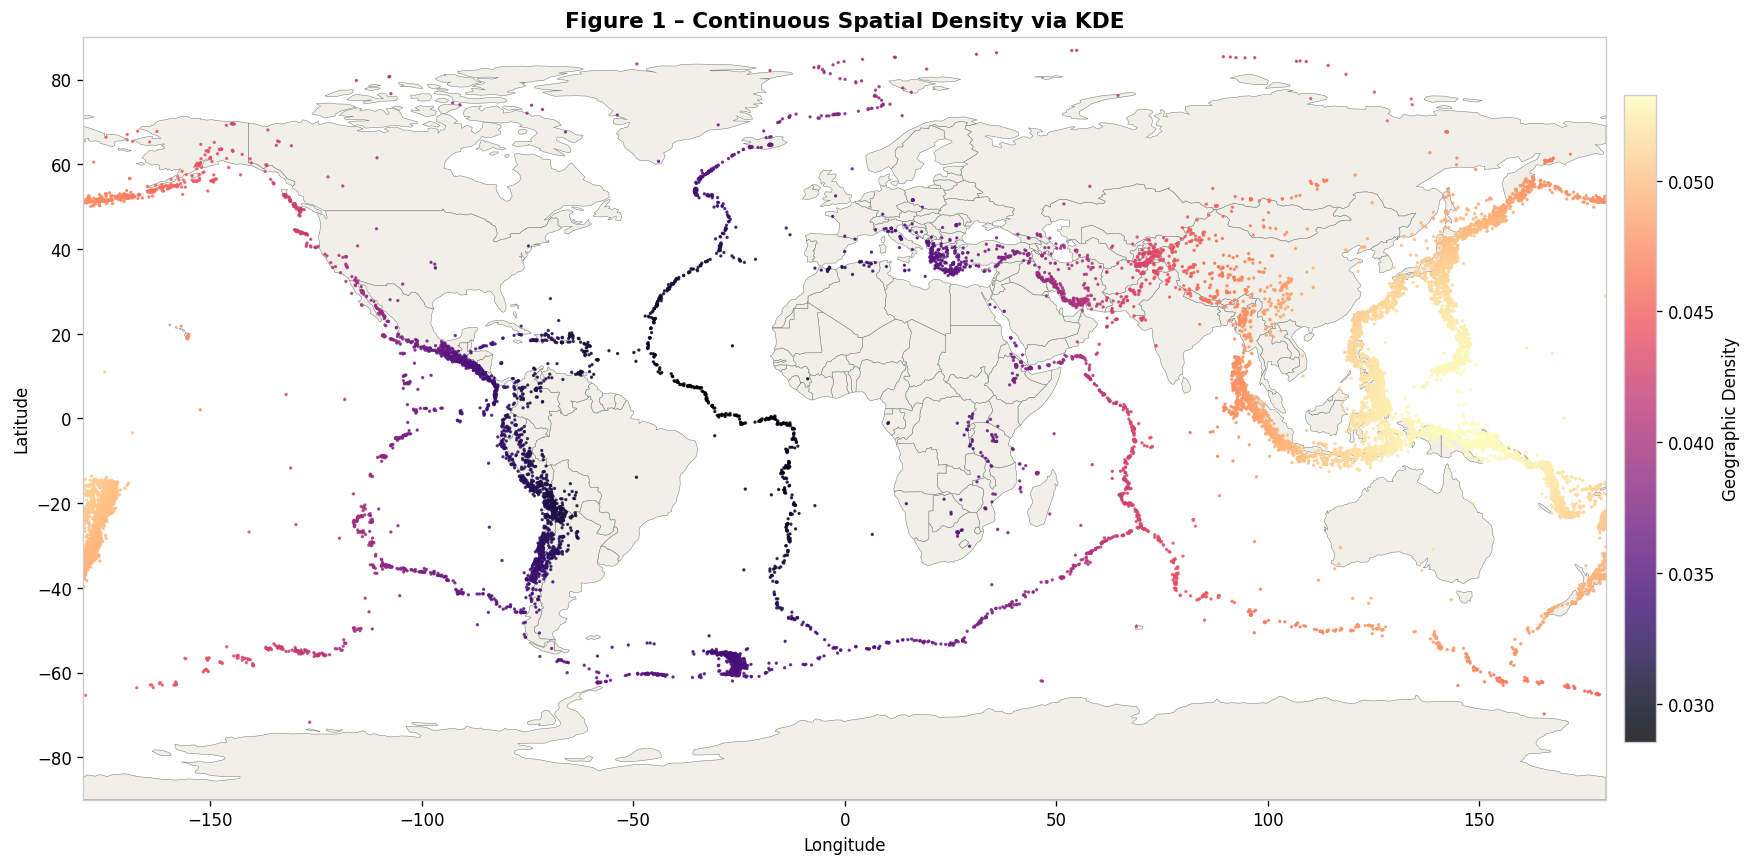

In [26]:

# VIZ 1 – KDE Spatial Density Continuous Map
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
sc = ax.scatter(sample_kde['longitude'], sample_kde['latitude'],
                c=sample_kde['density_score'], cmap='magma', s=1, alpha=0.8)
cb = fig.colorbar(sc, ax=ax, pad=0.01, shrink=0.7)
cb.set_label('Geographic Density')
ax.set_title('Figure 1 – Continuous Spatial Density via KDE')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_ml_models/fig01_kde_map.png', dpi=150, bbox_inches='tight')
plt.show()


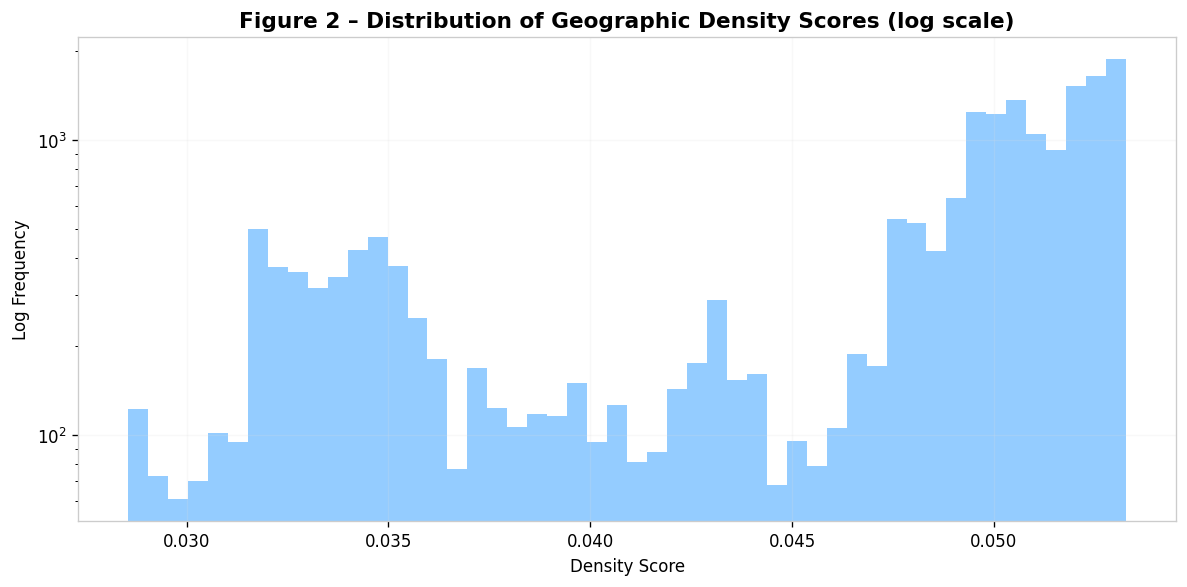

In [27]:

# VIZ 2 – Histogram of KDE Density Scores
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(sample_kde['density_score'], bins=50, color='#79c0ff', edgecolor='none', alpha=0.8)
ax.set_yscale('log')
ax.set_title('Figure 2 – Distribution of Geographic Density Scores (log scale)')
ax.set_xlabel('Density Score'); ax.set_ylabel('Log Frequency')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig02_kde_hist.png', dpi=150, bbox_inches='tight')
plt.show()


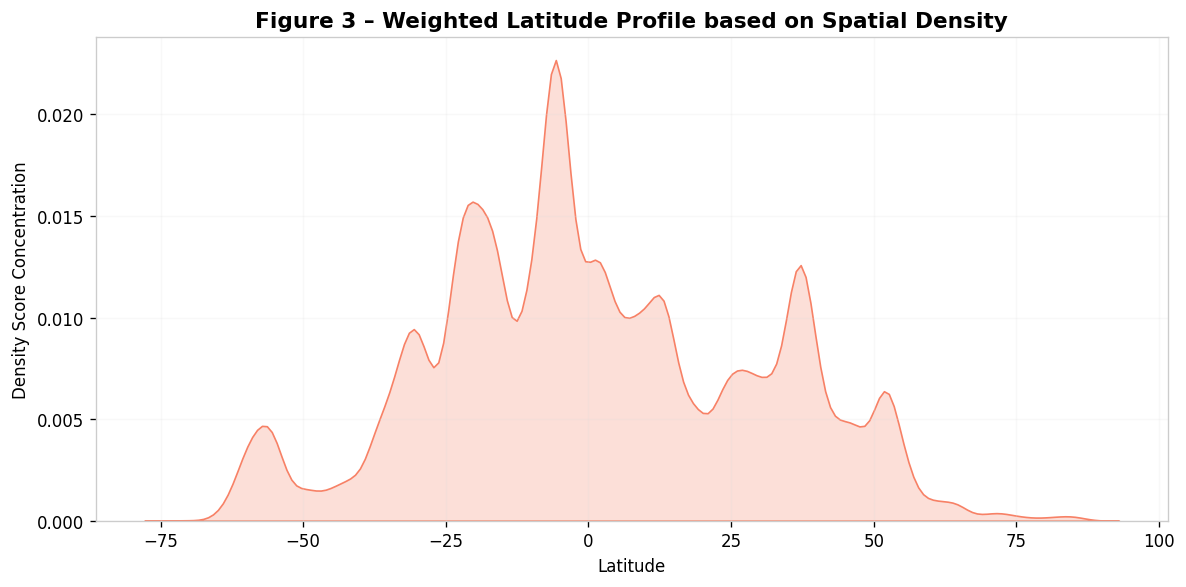

In [28]:

# VIZ 3 – KDE Density Latitude Profile
fig, ax = plt.subplots(figsize=(10,5))
sns.kdeplot(x=sample_kde['latitude'], weights=sample_kde['density_score'], bw_adjust=0.5, color='#f78166', fill=True, ax=ax)
ax.set_title('Figure 3 – Weighted Latitude Profile based on Spatial Density')
ax.set_xlabel('Latitude'); ax.set_ylabel('Density Score Concentration')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig03_kde_lat_profile.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. HDBSCAN Clustering

In [29]:

# ─── HDBSCAN MODELING ─────────────────────────────────────────────────────────
# HDBSCAN extends DBSCAN by converting it into a hierarchical clustering algorithm
# Useful for finding clusters of varying densities in geographic space
samp_clus = df.dropna(subset=['latitude','longitude','depth']).sample(min(15000, len(df)), random_state=1)
coords_3d = samp_clus[['latitude','longitude','depth']].values

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords_3d)

# Fit HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=10, gen_min_span_tree=True)
samp_clus['hdbscan_label'] = clusterer.fit_predict(coords_scaled)
samp_clus['cluster_prob'] = clusterer.probabilities_

n_clusters_hdb = len(set(samp_clus['hdbscan_label'])) - (1 if -1 in samp_clus['hdbscan_label'] else 0)
noise_hdb = (samp_clus['hdbscan_label'] == -1).sum()
print(f"HDBSCAN discovered {n_clusters_hdb} dynamic-density clusters.")
print(f"Noise points: {noise_hdb} / {len(samp_clus)}")


HDBSCAN discovered 165 dynamic-density clusters.
Noise points: 6199 / 15000


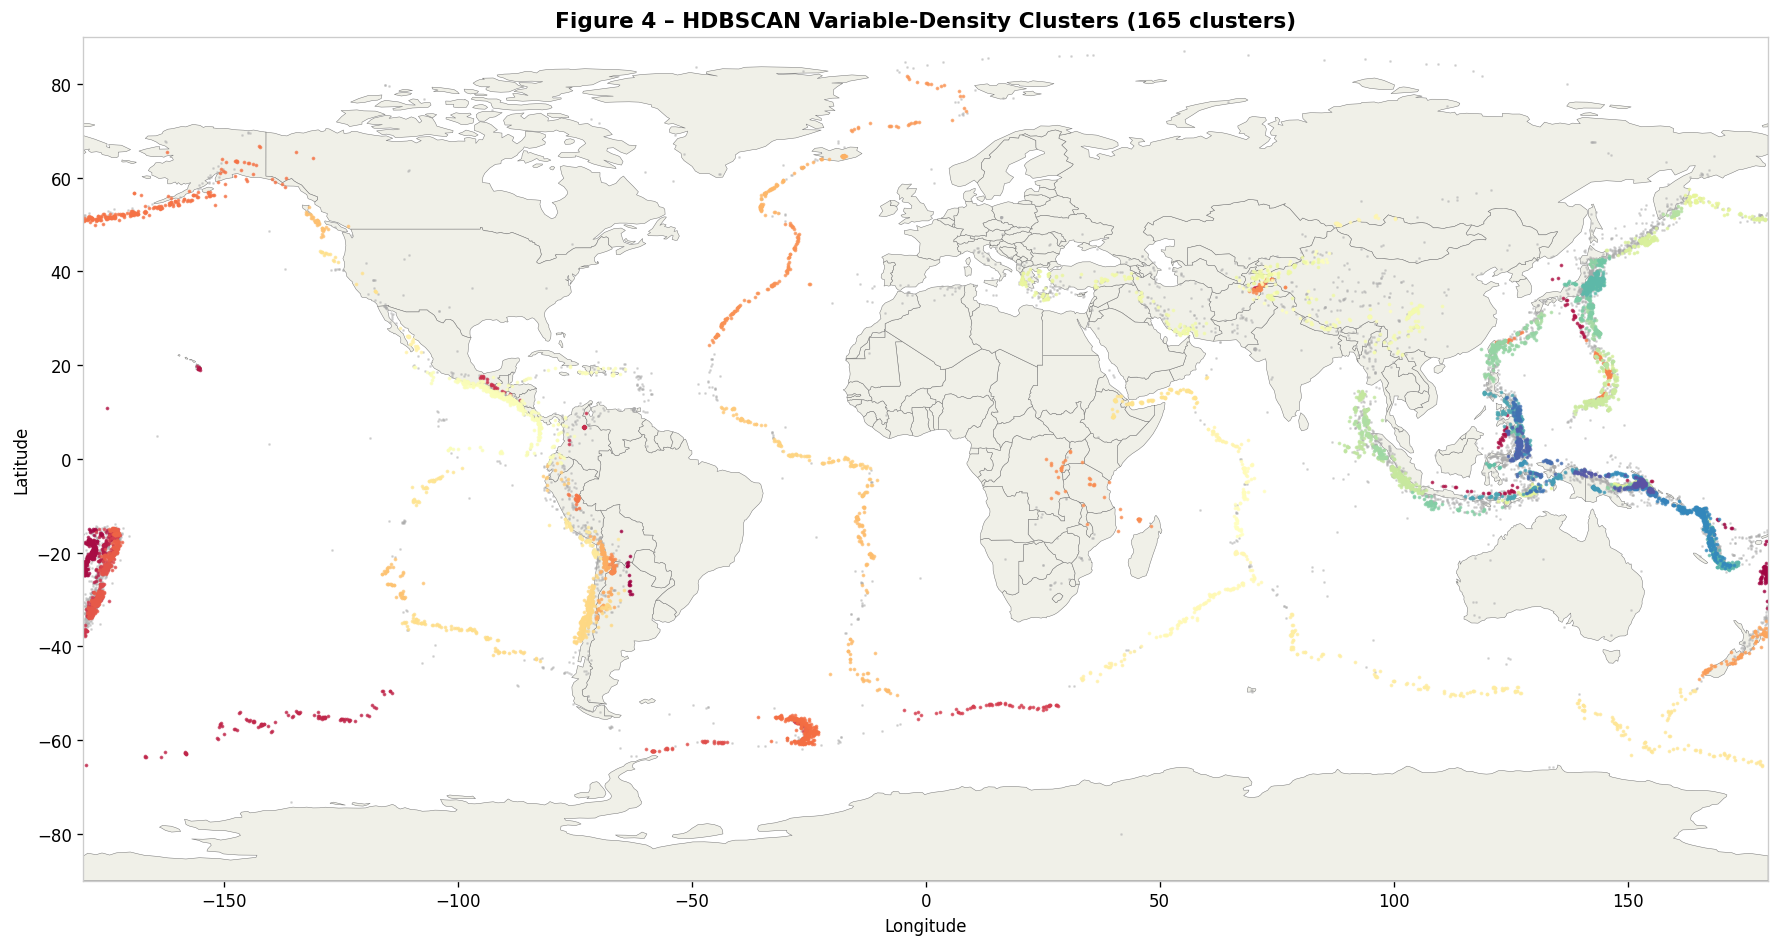

In [30]:

# VIZ 4 – HDBSCAN Cluster Map
unique_labels_hdb = set(samp_clus['hdbscan_label'])
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)

# plot noise
noise = samp_clus[samp_clus['hdbscan_label'] == -1]
ax.scatter(noise['longitude'], noise['latitude'], c='#aaaaaa', s=0.5, alpha=0.4, label='Noise')

cmap = plt.cm.get_cmap('Spectral', max(n_clusters_hdb, 1))
for i, lbl in enumerate([l for l in unique_labels_hdb if l != -1]):
    sub = samp_clus[samp_clus['hdbscan_label'] == lbl]
    ax.scatter(sub['longitude'], sub['latitude'], c=[cmap(i)], s=1.5, alpha=0.7)

ax.set_title(f'Figure 4 – HDBSCAN Variable-Density Clusters ({n_clusters_hdb} clusters)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_ml_models/fig04_hdbscan_map.png', dpi=150, bbox_inches='tight')
plt.show()


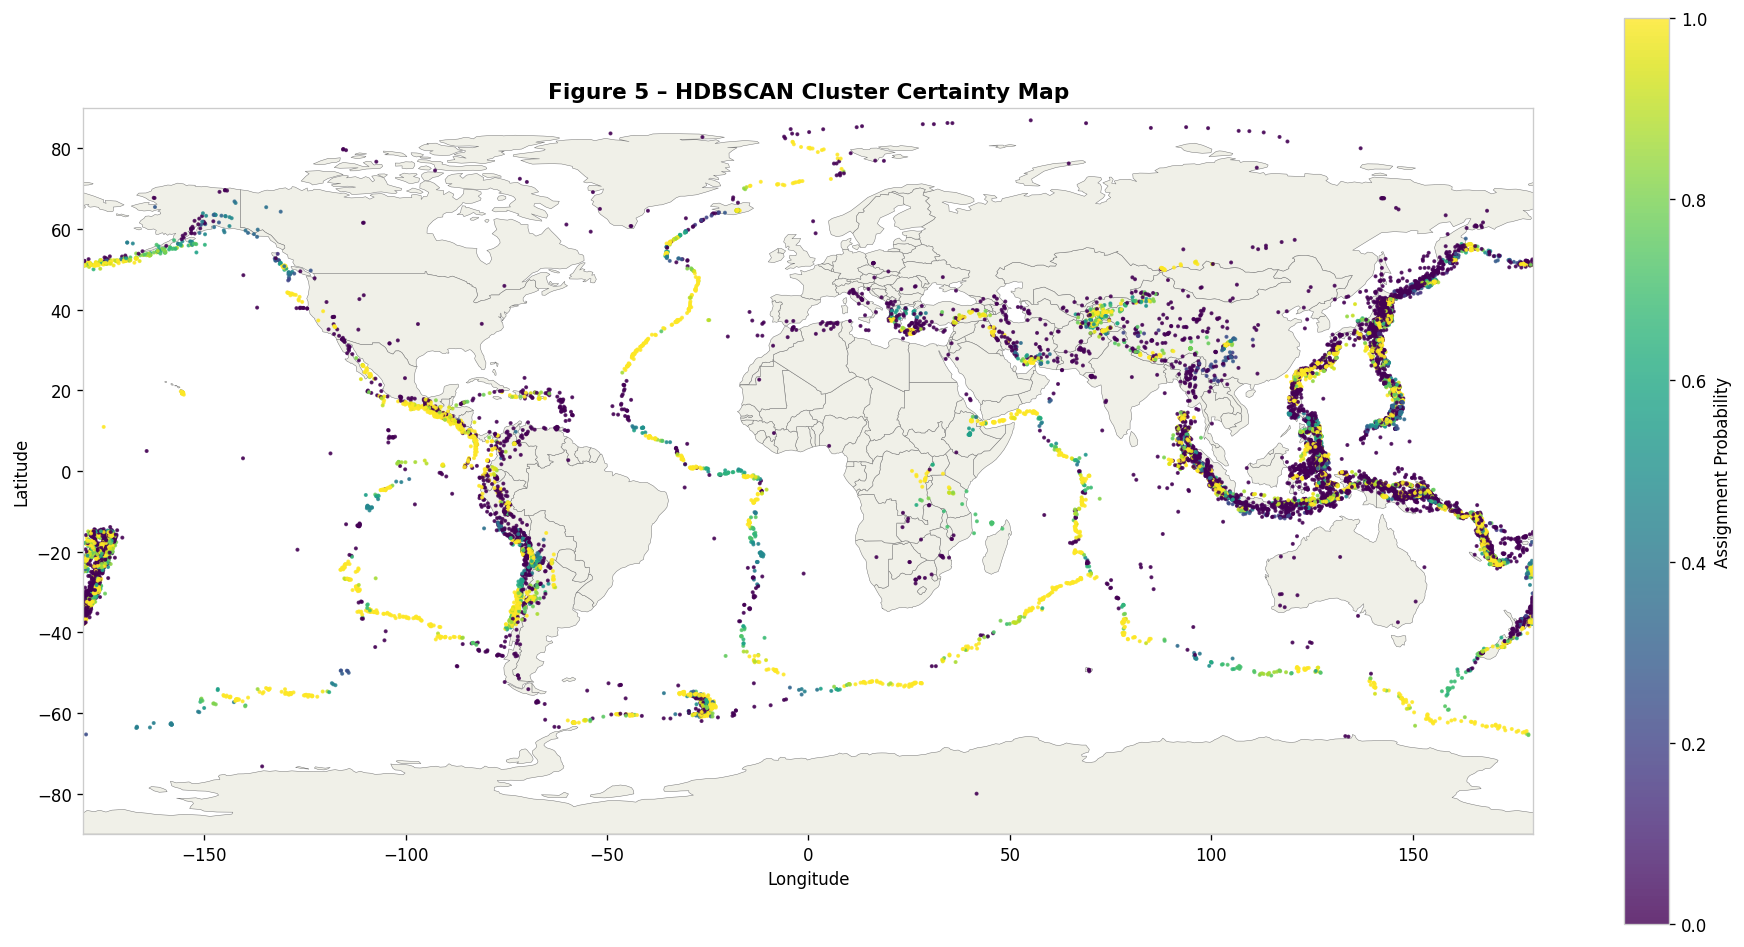

In [31]:

# VIZ 5 – HDBSCAN Cluster Assignment Probabilities
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
sc = ax.scatter(samp_clus['longitude'], samp_clus['latitude'],
                c=samp_clus['cluster_prob'], cmap='viridis', s=2, alpha=0.8)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Assignment Probability')
ax.set_title('Figure 5 – HDBSCAN Cluster Certainty Map')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_ml_models/fig05_hdbscan_prob.png', dpi=150, bbox_inches='tight')
plt.show()


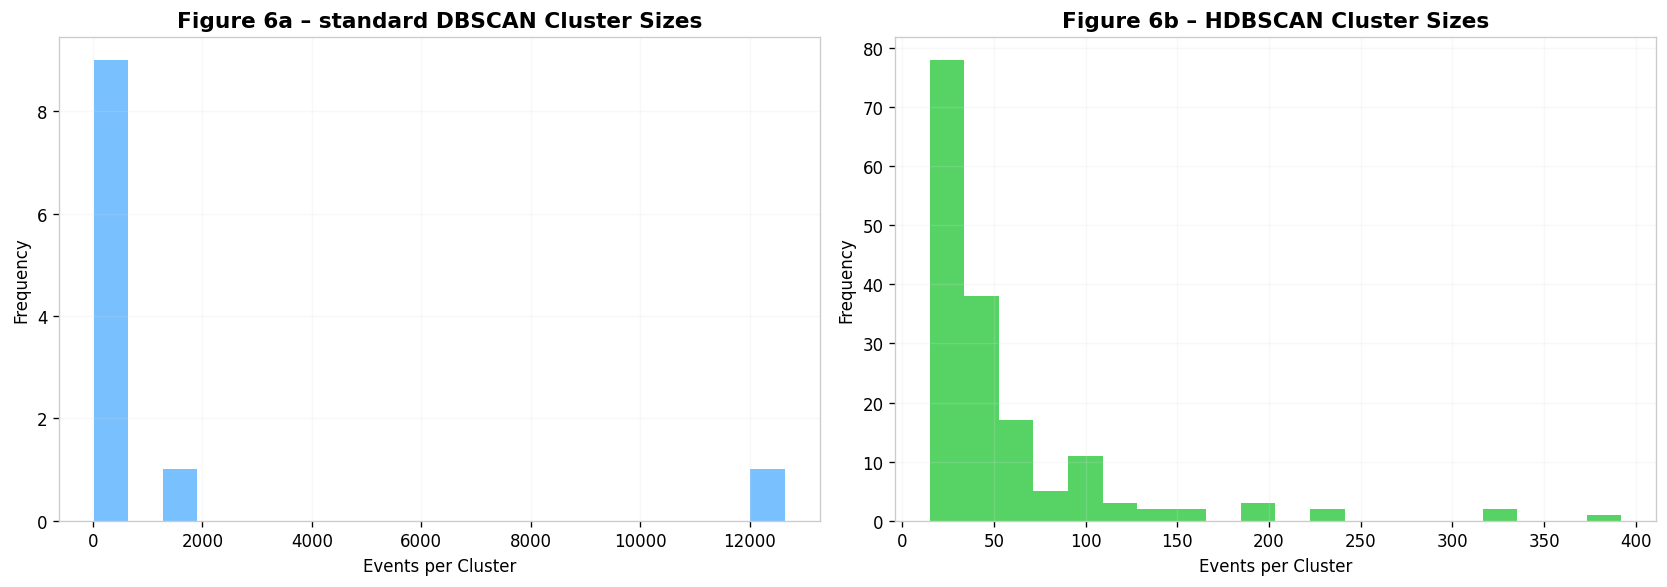

In [32]:

# VIZ 6 – DBSCAN vs HDBSCAN Cluster Size Distribution
# Run quick DBSCAN to compare
db_comp = DBSCAN(eps=0.2, min_samples=10).fit_predict(coords_scaled)
samp_clus['dbscan_comp_label'] = db_comp

fig, axes = plt.subplots(1, 2, figsize=(14,5))
db_sizes = samp_clus[samp_clus['dbscan_comp_label']!=-1]['dbscan_comp_label'].value_counts()
hdb_sizes = samp_clus[samp_clus['hdbscan_label']!=-1]['hdbscan_label'].value_counts()

axes[0].hist(db_sizes, bins=20, color='#79c0ff')
axes[0].set_title('Figure 6a – standard DBSCAN Cluster Sizes')
axes[0].set_xlabel('Events per Cluster'); axes[0].set_ylabel('Frequency')

axes[1].hist(hdb_sizes, bins=20, color='#56d364')
axes[1].set_title('Figure 6b – HDBSCAN Cluster Sizes')
axes[1].set_xlabel('Events per Cluster'); axes[1].set_ylabel('Frequency')

for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig06_cluster_size_compare.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Gaussian Mixture Model (Soft Clustering)

In [33]:

# ─── GMM MODELING ─────────────────────────────────────────────────────────────
# GMM allows for soft clustering and captures elliptic regional behaviors natively
K_gmm = 15
gmm = GaussianMixture(n_components=K_gmm, covariance_type='full', random_state=42)
samp_gmm = df.sample(min(25000, len(df)), random_state=123).copy()
coords_scaled_gmm = StandardScaler().fit_transform(samp_gmm[['latitude','longitude','depth']])

samp_gmm['gmm_label'] = gmm.fit_predict(coords_scaled_gmm)
probs = gmm.predict_proba(coords_scaled_gmm)
samp_gmm['gmm_uncertainty'] = 1 - probs.max(axis=1) # High uncertainty = boundary regions
print("GMM Model fitted ")


GMM Model fitted 


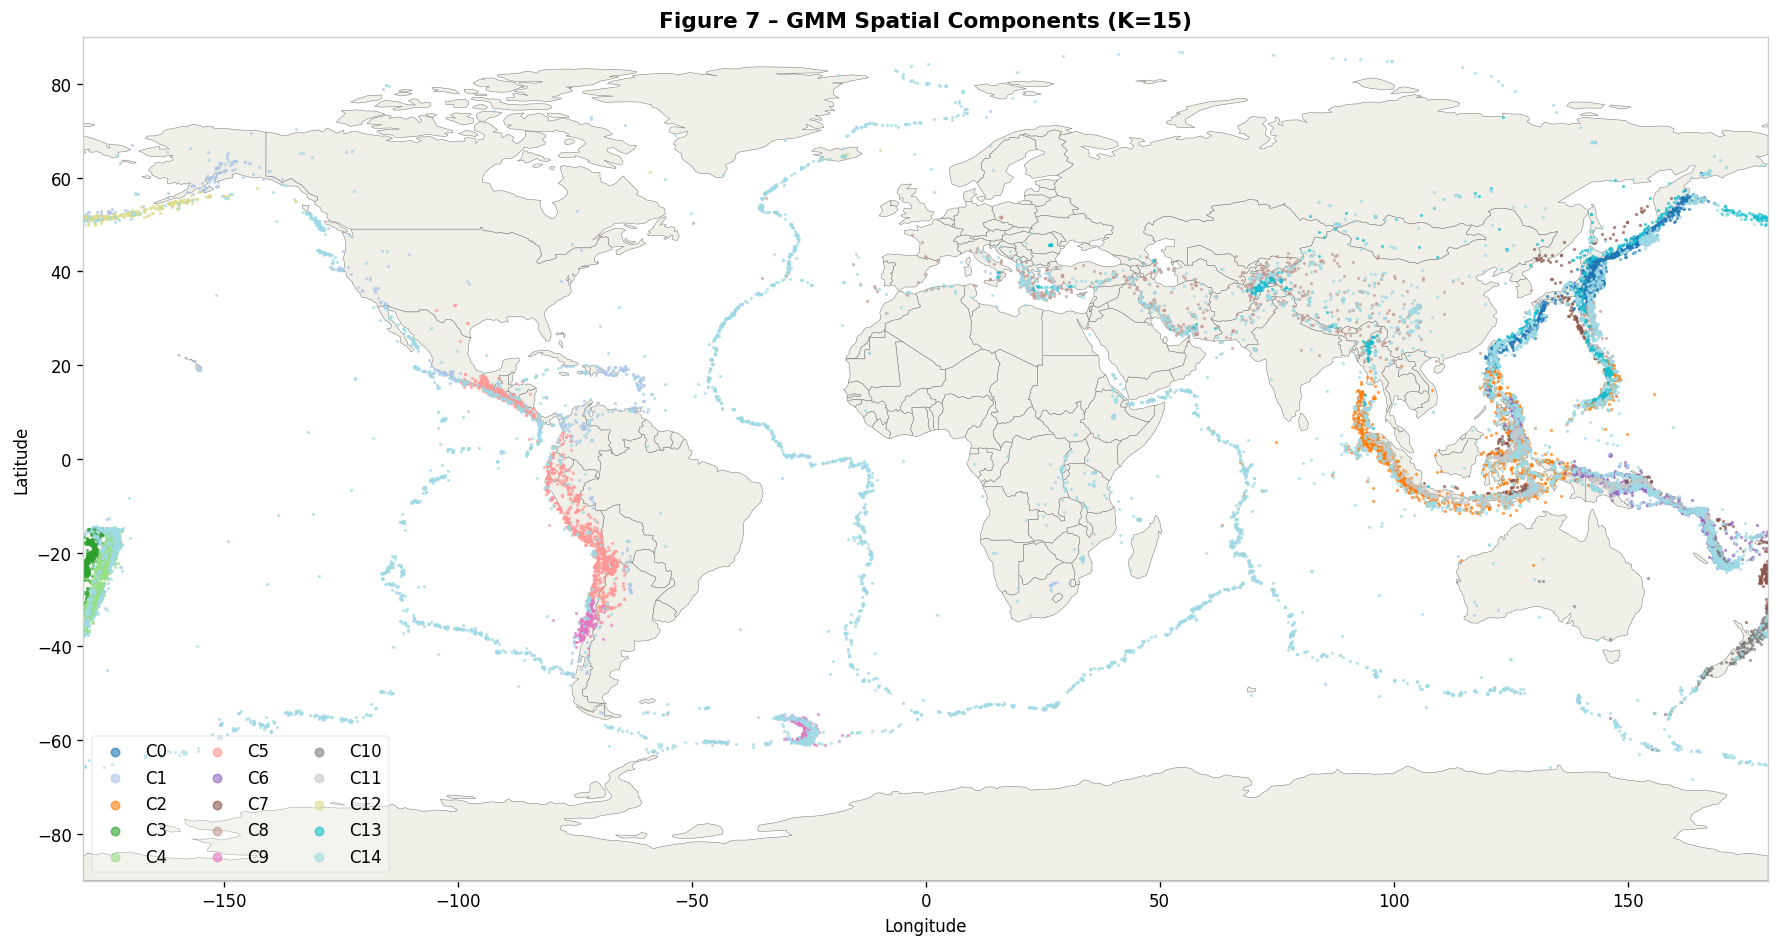

In [34]:

# VIZ 7 – GMM Component Map
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
cmap_gmm = plt.cm.get_cmap('tab20', K_gmm)
for k in range(K_gmm):
    sub = samp_gmm[samp_gmm['gmm_label'] == k]
    ax.scatter(sub['longitude'], sub['latitude'], c=[cmap_gmm(k)], s=1, alpha=0.6, label=f'C{k}')
ax.legend(markerscale=5, ncol=3, loc='lower left', framealpha=0.3)
ax.set_title(f'Figure 7 – GMM Spatial Components (K={K_gmm})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_ml_models/fig07_gmm_map.png', dpi=150, bbox_inches='tight')
plt.show()


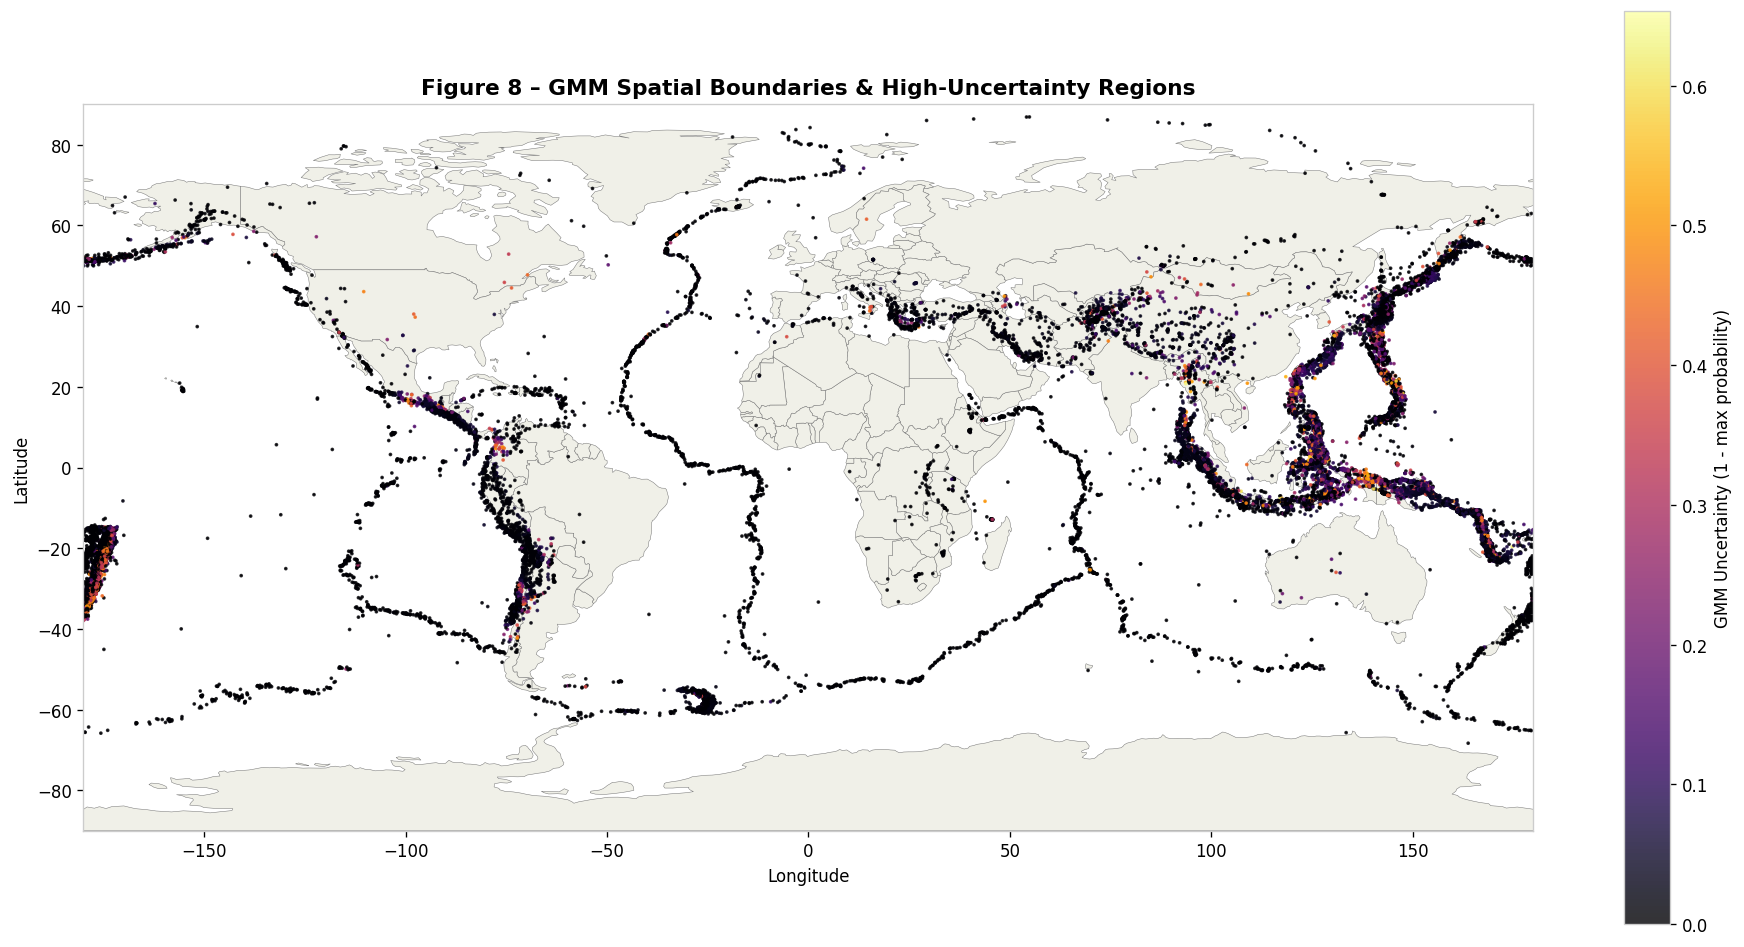

In [35]:

# VIZ 8 – GMM Assignment Uncertainty (Soft Clustering Boundaries)
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
sc = ax.scatter(samp_gmm['longitude'], samp_gmm['latitude'],
                c=samp_gmm['gmm_uncertainty'], cmap='inferno', s=1.5, alpha=0.8)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('GMM Uncertainty (1 - max probability)')
ax.set_title('Figure 8 – GMM Spatial Boundaries & High-Uncertainty Regions')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_ml_models/fig08_gmm_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. XGBoost: Predicting Magnitude using Spatial Geography

In [36]:

# ─── XGBOOST MAGNITUDE PREDICTION ─────────────────────────────────────────────
# Can we predict event magnitude based on its exact 3D location and local spatial lag?
features_xgb = ['latitude', 'longitude', 'depth', 'spatial_lag_mag']
# If the engineered CSV is loaded, use more spatial features
if 'spatial_density' in df.columns:
    features_xgb.append('spatial_density')
if 'dist_to_nearest_km' in df.columns:
    features_xgb.append('dist_to_nearest_km')

df_xgb = df.dropna(subset=features_xgb + ['mag']).copy()

X = df_xgb[features_xgb].values
y = df_xgb['mag'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=7,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
preds_xgb = xgb_model.predict(X_test)

mse_xgb = mean_squared_error(y_test, preds_xgb)
r2_xgb = r2_score(y_test, preds_xgb)
print(f"XGBoost Model - MSE: {mse_xgb:.4f}, R²: {r2_xgb:.4f}")


XGBoost Model - MSE: 0.1404, R²: 0.0573


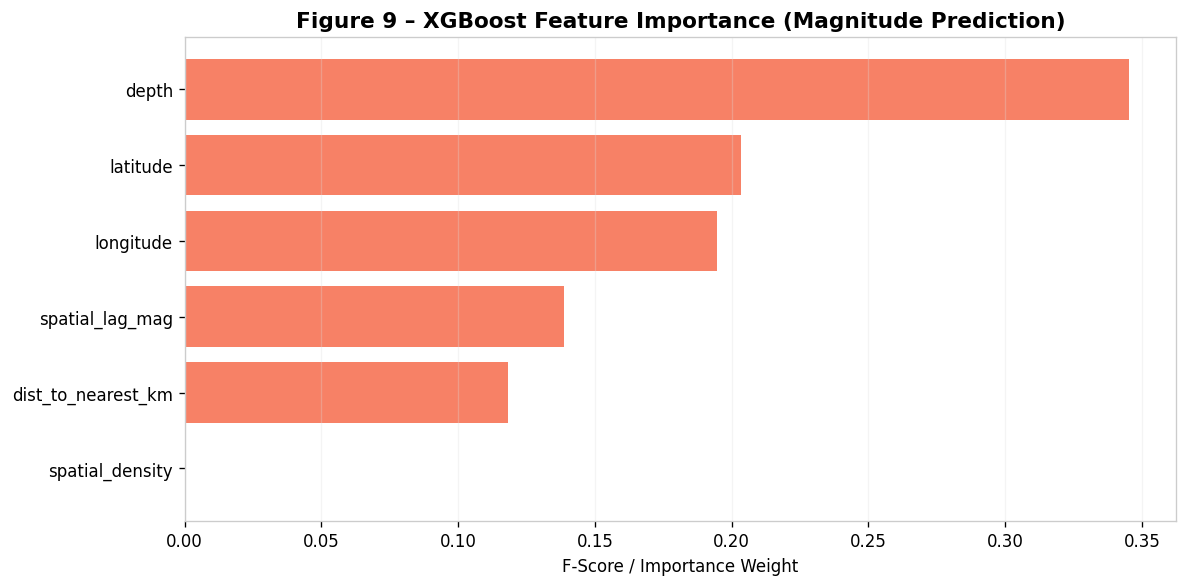

In [37]:

# VIZ 9 – XGBoost Feature Importances
importances = xgb_model.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(np.array(features_xgb)[idx], importances[idx], color='#f78166')
ax.set_title('Figure 9 – XGBoost Feature Importance (Magnitude Prediction)')
ax.set_xlabel('F-Score / Importance Weight')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig09_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()


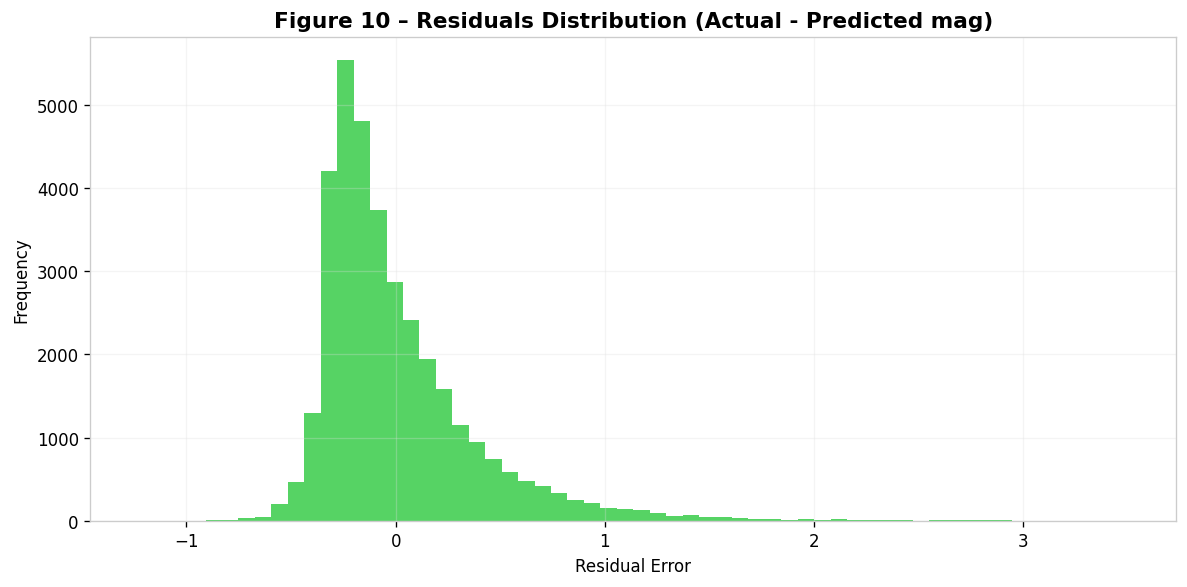

In [38]:

# VIZ 10 – XGBoost Prediction Error Distribution
errors_xgb = y_test - preds_xgb
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(errors_xgb, bins=60, color='#56d364', edgecolor='none')
ax.set_title('Figure 10 – Residuals Distribution (Actual - Predicted mag)')
ax.set_xlabel('Residual Error'); ax.set_ylabel('Frequency')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig10_xgb_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Random Forest: Structured Zones & Lag modeling

In [39]:

# ─── RANDOM FOREST ────────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, n_jobs=-1, random_state=13)
rf_model.fit(X_train, y_train)
preds_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, preds_rf)
r2_rf = r2_score(y_test, preds_rf)
print(f"Random Forest - MSE: {mse_rf:.4f}, R²: {r2_rf:.4f}")


Random Forest - MSE: 0.1376, R²: 0.0761


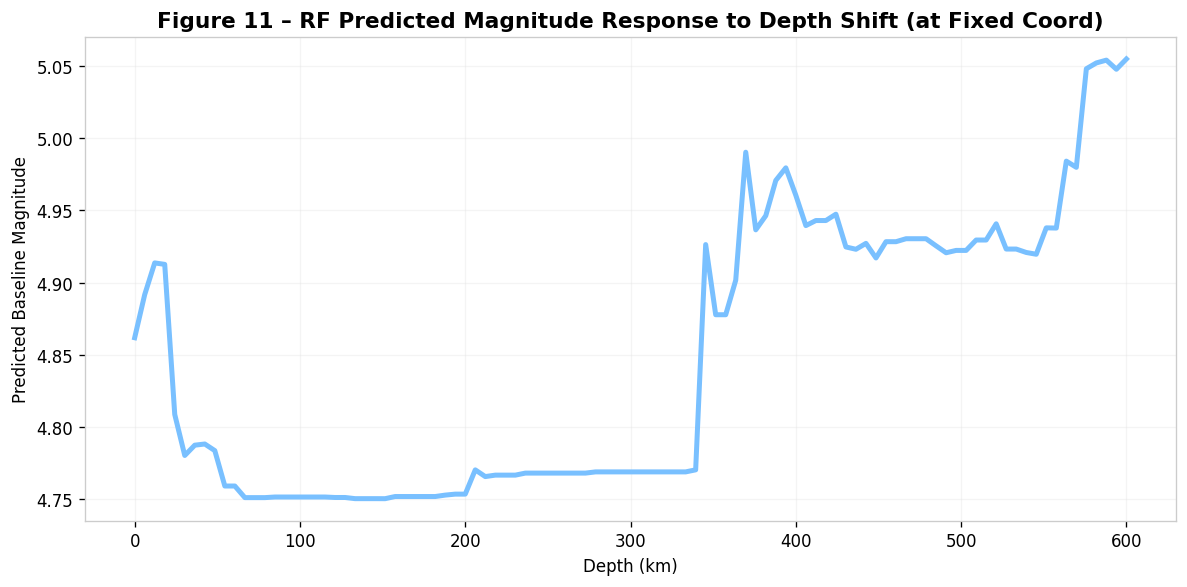

In [40]:

# VIZ 11 – RF Partial Profile for Depth Trajectory
# Generate a synthetic grid
lat_grid = np.linspace(-60, 60, 100)
lon_grid = np.linspace(-180, 180, 150)
grid_lats, grid_lons = np.meshgrid(lat_grid, lon_grid)

# Hold other features at median
median_depth = df_xgb['depth'].median()
median_lag = df_xgb['spatial_lag_mag'].median()
base_ft = []

for lt, ln in zip(grid_lats.ravel(), grid_lons.ravel()):
    row = [lt, ln, median_depth, median_lag]
    if 'spatial_density' in features_xgb:
        row.append(df_xgb['spatial_density'].median())
    if 'dist_to_nearest_km' in features_xgb:
        row.append(df_xgb['dist_to_nearest_km'].median())
    base_ft.append(row)

synthetic_preds = rf_model.predict(np.array(base_ft)).reshape(grid_lats.shape)
depths = np.linspace(0, 600, 100)
# Pick a random high-activity coordinate (Japan subduction approx)
jp_lat, jp_lon = 37.0, 142.0

dp_ft = []
for d in depths:
    row = [jp_lat, jp_lon, d, median_lag]
    if 'spatial_density' in features_xgb:
        row.append(df_xgb['spatial_density'].median())
    if 'dist_to_nearest_km' in features_xgb:
        row.append(df_xgb['dist_to_nearest_km'].median())
    dp_ft.append(row)

depth_surf_preds = rf_model.predict(np.array(dp_ft))

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(depths, depth_surf_preds, color='#79c0ff', lw=3)
ax.set_title('Figure 11 – RF Predicted Magnitude Response to Depth Shift (at Fixed Coord)')
ax.set_xlabel('Depth (km)'); ax.set_ylabel('Predicted Baseline Magnitude')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig11_rf_depth_response.png', dpi=150, bbox_inches='tight')
plt.show()


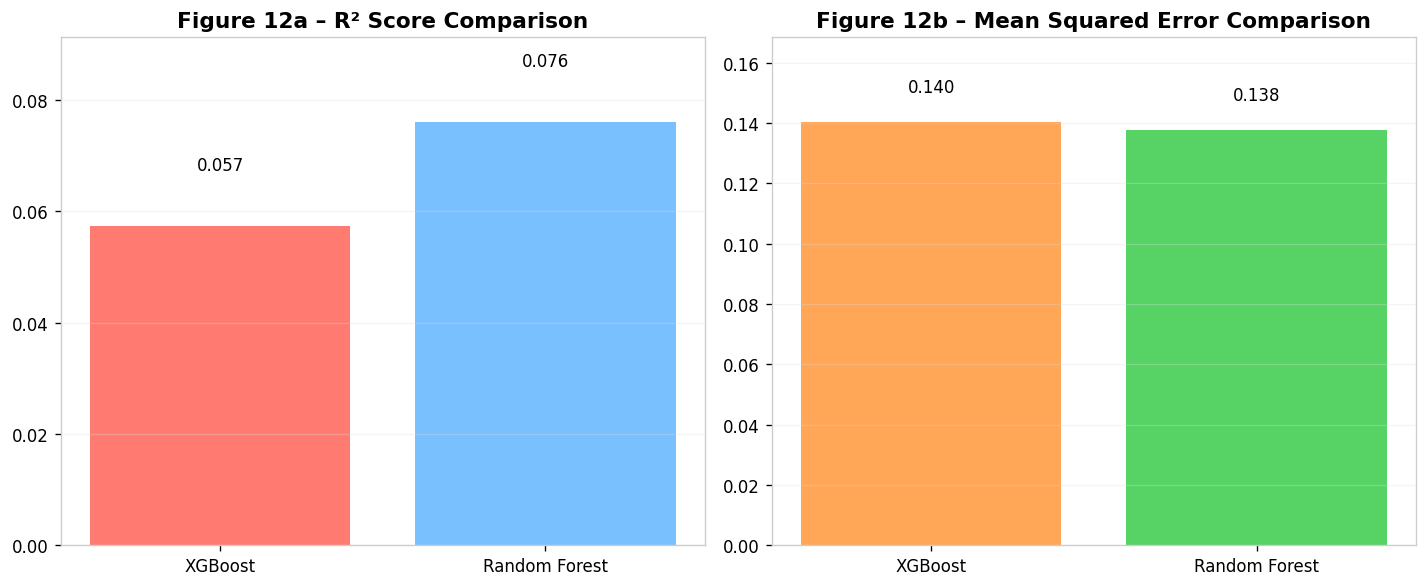

In [41]:

# VIZ 12 – Model Performance Comparison (R² & MSE)
models = ['XGBoost', 'Random Forest']
r2s = [r2_xgb, r2_rf]
mses = [mse_xgb, mse_rf]

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].bar(models, r2s, color=['#ff7b72', '#79c0ff'])
axes[0].set_title('Figure 12a – R² Score Comparison')
axes[0].set_ylim(0, max(r2s)*1.2)
for i, v in enumerate(r2s): axes[0].text(i, v+0.01, f"{v:.3f}", ha='center')

axes[1].bar(models, mses, color=['#ffa657', '#56d364'])
axes[1].set_title('Figure 12b – Mean Squared Error Comparison')
axes[1].set_ylim(0, max(mses)*1.2)
for i, v in enumerate(mses): axes[1].text(i, v+0.01, f"{v:.3f}", ha='center')

for ax in axes: ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_ml_models/fig12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [42]:

print("=" * 60)
print("SPATIAL ML MODELS SUMMARY")
print("=" * 60)
print(f"Total clustering algorithms evaluated : 3 (HDBSCAN, DBSCAN_comp, GMM)")
print(f"Total predictive models evaluated   : 2 (XGBoost, RandomForest)")
print()
print(f"XGBoost R² Performance : {r2_xgb:.4f} | MSE: {mse_xgb:.4f}")
print(f"RF R² Performance      : {r2_rf:.4f} | MSE: {mse_rf:.4f}")
print("=" * 60)
print("Visualizations saved to 'spatial_ml_models' directory")


SPATIAL ML MODELS SUMMARY
Total clustering algorithms evaluated : 3 (HDBSCAN, DBSCAN_comp, GMM)
Total predictive models evaluated   : 2 (XGBoost, RandomForest)

XGBoost R² Performance : 0.0573 | MSE: 0.1404
RF R² Performance      : 0.0761 | MSE: 0.1376
Visualizations saved to 'spatial_ml_models' directory
